In [1]:
!pip install -r requirements.txt

In [2]:
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt

## Data Preprocessing

To prepare the [UAV Drone Dataset](https://www.kaggle.com/datasets/dasmehdixtr/drone-dataset-uav) for PCA, we transform raw images into a standardized mathematical matrix $X$.

### 1. Extraction (YOLO Parsing)
Each image has a `.txt` file with normalized coordinates ($x_{center}, y_{center}, w, h$). We use this data to **crop** the drone, removing background noise like trees or sky. 

### 2. Standardization
For PCA to function, all input vectors must have the same dimensionality:
* **Grayscale:** Reduces data from 3 channels (RGB) to 1.
* **Resizing:** Every crop is scaled to a uniform $64 \times 64$ size.
* **Flattening:** The $2D$ image matrix is unrolled into a $1D$ vector of $4096$ pixels ($n = 4096$). 

### 3. Normalization
Pixel values are scaled to $[0, 1]$ to ensure the variance in PCA is driven by the drone's structural features rather than lighting conditions. 

**Result:** A data matrix $X$ where each row is a cleaned, standardized drone signature.

In [3]:
def read_image(img_path):
    """Read image using CV library"""
    return cv2.imread(img_path)

def read_yolo_file(txt_path):
    """Read text yolo file"""
    with open(txt_path, 'r', encoding='utf-8') as f:
        drones = []

        for line in f:
            data = line.strip().split()
            if not data or len(data) < 5:
                continue
            drone = {}
            drone['class_id'] = int(data[0])
            drone['x_center_norm'] = float(data[1])
            drone['y_center_norm'] = float(data[2])
            drone['width_norm'] = float(data[3])
            drone['height_norm'] = float(data[4])
            drones.append(drone)
    return drones

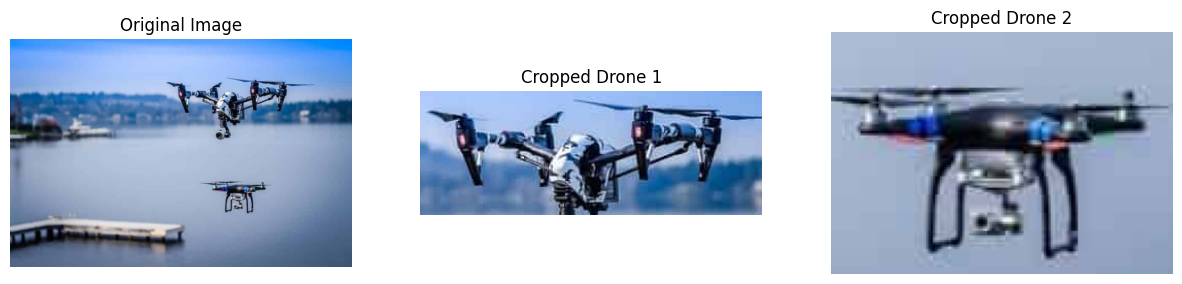

In [4]:
def crop_yolo_object(image, drones_yolo):
    """Croping the image using information from YOLO"""
    if image is None:
        return None

    if not drones_yolo:
        return None

    img_height, img_width = image.shape[:2]
    cropped_images = []

    for drone_yolo in drones_yolo:
        x_center = drone_yolo['x_center_norm'] * img_width
        y_center = drone_yolo['y_center_norm'] * img_height
        box_width = drone_yolo['width_norm'] * img_width
        box_height = drone_yolo['height_norm'] * img_height

        x1 = int(x_center - (box_width / 2))
        y1 = int(y_center - (box_height / 2))
        x2 = int(x_center + (box_width / 2))
        y2 = int(y_center + (box_height / 2))

        x1 = max(0, x1)
        y1 = max(0, y1)
        x2 = min(img_width, x2)
        y2 = min(img_height, y2)

        cropped_image = image[y1:y2, x1:x2]
        cropped_images.append(cropped_image)

    return cropped_images


def crop_drone(img_path, yolo_path):
    """Crop images to leave only drone"""
    img = read_image(img_path)
    drones_yolo = read_yolo_file(yolo_path)
    return crop_yolo_object(img, drones_yolo)

img_path = './archive/drone_dataset_yolo/dataset_txt/0010.jpg'
txt_path = './archive/drone_dataset_yolo/dataset_txt/0010.txt'

cropped_drones_list = crop_drone(img_path, txt_path)
orig_img = read_image(img_path)

if cropped_drones_list is not None and orig_img is not None:
    orig_img_rgb = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
    total_images = 1 + len(cropped_drones_list)
    fig, axes = plt.subplots(1, total_images, figsize=(5 * total_images, 5))

    if total_images == 2:
        axes = [axes[0], axes[1]]

    axes[0].imshow(orig_img_rgb)
    axes[0].axis('off')
    axes[0].set_title("Original Image")

    for i, cropped_img in enumerate(cropped_drones_list):
        img_rgb = cv2.cvtColor(cropped_img, cv2.COLOR_BGR2RGB)

        axes[i + 1].imshow(img_rgb)
        axes[i + 1].axis('off')
        axes[i + 1].set_title(f"Cropped Drone {i + 1}")

    plt.show()
else:
    print("Failed to process the image.")

### Load the Images

In [5]:
def flatten_image(image, target_size=(64, 64)):
    """Resize the image and flatten it, normalized to [0, 1]"""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = cv2.resize(image, target_size)
    return image.flatten() / 255.0

In [6]:
def create_train_test_split(dataset_folder, train_ratio=0.85):
    """Split drone dataset into training and test sets"""
    drone_files = sorted([f for f in os.listdir(dataset_folder)
                         if f.endswith(('.jpg', '.png'))])

    n_drones = len(drone_files)
    n_train = int(n_drones * train_ratio)

    train_files = drone_files[:n_train]
    test_files = drone_files[n_train:]

    return train_files, test_files

def load_drone_dataset(dataset_folder, file_list):
    """Load drone images from file list"""
    dataset_matrix = []

    for filename in file_list:
        img_path = os.path.join(dataset_folder, filename)
        txt_path = img_path.rsplit('.', 1)[0] + '.txt'

        if os.path.exists(txt_path):
            img = read_image(img_path)
            drones_yolo = read_yolo_file(txt_path)
            cropped_drones_list = crop_yolo_object(img, drones_yolo)

            if cropped_drones_list is not None:
                for drone_img in cropped_drones_list:
                    flat_drone = flatten_image(drone_img, target_size=(64, 64))
                    dataset_matrix.append(flat_drone)

    return np.array(dataset_matrix) if dataset_matrix else np.array([])

def load_non_drone_dataset(non_drone_folder):
    """Load non-drone images (background, birds, etc.)"""
    dataset_matrix = []

    for filename in os.listdir(non_drone_folder):
        if filename.endswith(('.jpg', '.png')):
            img_path = os.path.join(non_drone_folder, filename)
            img = read_image(img_path)

            if img is not None:
                # Resize and flatten full image (no cropping needed)
                flat_img = flatten_image(img, target_size=(64, 64))
                dataset_matrix.append(flat_img)

    return np.array(dataset_matrix) if dataset_matrix else np.array([])

# Split drone dataset
drone_folder = './archive/drone_dataset_yolo/dataset_txt'
train_files, test_files = create_train_test_split(drone_folder, train_ratio=0.85)

print(f"Drone Training Images: {len(train_files)} files")
print(f"Drone Test Images: {len(test_files)} files")

# Load datasets
X_train_drone = load_drone_dataset(drone_folder, train_files)
X_test_drone = load_drone_dataset(drone_folder, test_files)

# Load non-drone test images
non_drone_folder = './archive/Dataset/test/images'
X_test_non_drone = load_non_drone_dataset(non_drone_folder)

print(f"\nDataset Shapes:")
print(f"X_train_drone: {X_train_drone.shape}")
print(f"X_test_drone: {X_test_drone.shape}")
print(f"X_test_non_drone: {X_test_non_drone.shape}")

Drone Training Images: 1155 files
Drone Test Images: 204 files

Dataset Shapes:
X_train_drone: (1262, 4096)
X_test_drone: (224, 4096)
X_test_non_drone: (889, 4096)


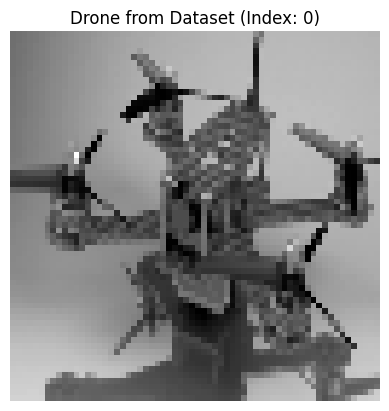

In [7]:
def show_drone_from_matrix(X, index=0, img_size=(64, 64)):
    """
    Displays a single image from the processed dataset matrix X.

    :param X: Dataset matrix (NumPy array)
    :param index: Index of the image to display (starting from 0)
    :param img_size: The target dimensions used during preprocessing (default 64x64)
    """
    # Check if the requested index exists in the matrix
    if index >= len(X):
        print(f"Error: The dataset contains only {len(X)} images. Index is out of bounds.")
        return

    # 1. Extract the specific row (vector) from the matrix
    flat_drone = X[index]

    # 2. Reshape the 1D vector (e.g., length 4096)
    # back into a 2D image matrix (e.g., 64x64)
    drone_2d = flat_drone.reshape(img_size)

    # 3. Display the result using a grayscale colormap
    plt.imshow(drone_2d, cmap='gray')
    plt.title(f"Drone from Dataset (Index: {index})")
    plt.axis('off')
    plt.show()

# Show example drone from unseen test set (once data is loaded)

if len(X_test_drone) > 0:
    show_drone_from_matrix(X_test_drone, index=0)

## Dataset Organization

We organize our data into proper **training** and **testing** splits:

| Set | Images | Type | 
|-----|--------|------|
| **Training** | 1,150 | Drones |
| **Test - Drones** | 209 | Drones |
| **Test - Non-Drones** | 889 | Background/Birds |

This ensures we evaluate **both** the ability to recognize drones AND reject false positives.

In [8]:
def flatten_image(image, target_size=(64, 64)):
    """Resize the image and flatten it, normalized to [0, 1]"""
    image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = cv2.resize(image, target_size)
    return image.flatten() / 255.0

Each image can be represented as a matrix of pixels. The RGB format involves a complex setup of three matrices representing the intensity of each color channel. To simplify calculations and improve efficiency, we convert the image to grayscale, which works effectively for the following algorithms.

For an image represented as an $N \times M$ matrix, we flatten it into an $NM \times 1$ vector to execute subsequent vector operations.

### Data Normalization

The next step for the PCA algorithm is data normalization. We define our data matrix $X$ as:

$$X = [x_1, x_2, x_3, \ldots, x_n] \tag{1}$$

where $x_i$ are the flattened image vectors from our dataset.

### Mean Vector

We then calculate the mean vector:

$$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i \tag{2}$$

In [9]:
def calculate_mean_vector(X):
    mean_vector = np.mean(X, axis=0)
    return mean_vector

X = X_train_drone

X_mean = calculate_mean_vector(X)
print(f"X shape: {X.shape}")
print(f"X_mean shape: {X_mean.shape}")

X shape: (1262, 4096)
X_mean shape: (4096,)


### Centralized Data

The centralized data of the set is then represented as:

$$\bar{x}_i = x_i - \mu \tag{3}$$

In [10]:
def centralize_data(X, mean_vector):
    X_centered = X - mean_vector
    return X_centered

X_centered = centralize_data(X, X_mean)
print(f"X_centered shape: {X_centered.shape}")

X_centered shape: (1262, 4096)


### Covariance Matrix

The following step involves calculating the covariance matrix using the formula:

$$C = \frac{1}{n} \bar{X} \bar{X}^T \tag{4}$$

To optimize calculation for high-resolution images, we use a mathematical trick by defining a smaller matrix $C'$:

$$C' = \bar{X}^T \bar{X} \tag{5}$$

This allows us to process datasets where the number of images is much smaller than the number of pixels.

In [11]:
def calculate_covariance_matrix(X):
    # Center the data
    X_centered = centralize_data(X, calculate_mean_vector(X))
    # Calculate the covariance matrix
    covariance_matrix = np.cov(X_centered, rowvar=False)

    return covariance_matrix

print(calculate_covariance_matrix(X))

[[0.08618946 0.08417585 0.08169301 ... 0.0587147  0.0594151  0.0589275 ]
 [0.08417585 0.0855689  0.08277488 ... 0.05789392 0.05845406 0.05826948]
 [0.08169301 0.08277488 0.08351586 ... 0.05772036 0.05790724 0.05738767]
 ...
 [0.0587147  0.05789392 0.05772036 ... 0.0803283  0.07882539 0.07591288]
 [0.0594151  0.05845406 0.05790724 ... 0.07882539 0.08060695 0.07764261]
 [0.0589275  0.05826948 0.05738767 ... 0.07591288 0.07764261 0.07845174]]


## Eigenvectors and Eigenvalues

To proceed, we must utilize Eigenvectors and Eigenvalues. By definition, the transformation of an eigenvector $v$ by a matrix $A$ is:

$$Av = \lambda v \tag{6}$$

where $\lambda$ represents the eigenvalue.

Assuming $C' = \bar{X}^T \bar{X}$ is our $A$:

$$(\bar{X}^T \bar{X}) v = \lambda v \tag{7}$$

Left-multiplying by $\bar{X}$:

$$(\bar{X} \bar{X}^T)(\bar{X} v) = \lambda (\bar{X} v) \tag{8}$$

This proves that $(\bar{X} v)$ is the eigenvector of the large covariance matrix $C$.

## Power Method and Projection

We use the power method to find the dominant eigenvector:

$$x_{k+1} = \frac{A x_k}{\| A x_k \|} \tag{9}$$

This iterates until convergence. We then build matrix $Y$ (the "eigendrone" space) and project our data:

$$Z = Y^T \bar{X} \tag{10}$$

For a test image $x_{\text{test}}$, we center and project it:

$$Z_{\text{test}} = Y^T (x_{\text{test}} - \mu) \tag{11}$$

Finally, we calculate the Euclidean distance between projections. If the distance is below an experimental threshold, the object is classified as a drone.

In [12]:
def fast_pca_algorithm(X, num_components=None, max_iterations=100):
    """Compute PCA using power method on surrogate matrix X @ X.T (N×N, not D×D).
    Returns eigenvalues and eigenvectors (D×num_components) by mapping back from N×N space.
    """
    n_samples, n_features = X.shape
    X_mean = np.mean(X, axis=0)
    X_centered = X - X_mean

    if num_components is None:
        num_components = min(n_samples, n_features)


    C_surrogate = np.dot(X_centered, X_centered.T) / n_samples

    eigenvalues = []
    eigenvectors_pca_space = []
    C_working = C_surrogate.copy()

    for k in range(min(num_components, n_samples)):

        v = np.random.randn(C_working.shape[0])
        v = v / np.linalg.norm(v)

        for _ in range(max_iterations):
            v_new = np.dot(C_working, v)
            v_norm = np.linalg.norm(v_new)
            if v_norm < 1e-10:
                break
            v_new = v_new / v_norm

            if np.linalg.norm(v_new - v) < 1e-6:
                break
            v = v_new


        eigenvalue = np.dot(v, np.dot(C_working, v))
        eigenvalues.append(max(0, eigenvalue))


        y = np.dot(X_centered.T, v)
        y_norm = np.linalg.norm(y)
        if y_norm > 1e-10:
            y = y / y_norm
            eigenvectors_pca_space.append(y)

        # Deflate
        C_working = C_working - eigenvalue * np.outer(v, v)

    if not eigenvectors_pca_space:
        return np.array(eigenvalues), np.zeros((n_features, 0))

    return np.array(eigenvalues), np.column_stack(eigenvectors_pca_space)

def get_k_components(evals, evecs, variance_threshold=0.95):
    evals = np.maximum(evals, 0)
    total_variance = np.sum(evals)
    explained_variance = 0.0
    k = 0
    for e in evals:
        explained_variance += e / total_variance
        k += 1
        if explained_variance >= variance_threshold:
            break
    return evals[:k], evecs[:, :k]

evals_all, evecs_all = fast_pca_algorithm(X)
evals_1, evecs_1 = get_k_components(evals_all, evecs_all, variance_threshold=0.95)

print(f"Number of eigenvectors selected: {len(evals_1)}")
print(f"Shape of eigenvector matrix: {evecs_1.shape}")

mean_vector = calculate_mean_vector(X)

Number of eigenvectors selected: 441
Shape of eigenvector matrix: (4096, 441)


In [13]:
print(evals_1[:3])

[140.89777098  21.9251971   10.42732787]


### Testing

In [14]:
def z_test(X_test, mean_vector, eigenvectors):
    """
    Project test images into PCA space.
    X_test can be a single image (1D vector) or a matrix of multiple images.
    """

    X_centered = X_test - mean_vector

    projections = np.dot(X_centered, eigenvectors)
    return projections

In [15]:
def calculate_euclidean_distance(projections, threshold):
    """
    Calculate Euclidean distance from PCA origin and classify as drone or not.

    Args:
        projections: PCA projections of test images
        threshold: Distance threshold for drone classification

    Returns:
        distances: L2 norm distances from origin
        is_drone: Boolean array indicating drone(True) vs non-drone(False)
    """
    if projections.ndim == 1:
        projections = projections.reshape(1, -1)

    distances = np.linalg.norm(projections, axis=1)
    is_drone = distances < threshold

    return distances, is_drone


In [16]:

Z_train = z_test(X, mean_vector, evecs_1)

train_distances, _ = calculate_euclidean_distance(Z_train, threshold=float('inf'))


mean_dist = np.mean(train_distances)
max_dist = np.max(train_distances)

print(f"Mean distance for real drones: {mean_dist:.2f}")
print(f"Maximum distance for real drones: {max_dist:.2f}")


MY_THRESHOLD = mean_dist + np.std(train_distances)
print(f"Selected threshold for testing: {MY_THRESHOLD:.2f}")

Mean distance for real drones: 17.72
Maximum distance for real drones: 38.75
Selected threshold for testing: 22.90


In [17]:

Z_test_non_drone = z_test(X_test_non_drone, mean_vector, evecs_1)

# Compute distance statistics for non-drones
non_drone_distances = np.linalg.norm(Z_test_non_drone, axis=1)
mean_dist_non_drone = np.mean(non_drone_distances)
std_dist_non_drone = np.std(non_drone_distances)

print(f"Non-drone statistics:")
print(f"  Mean distance: {mean_dist_non_drone:.2f}")
print(f"  Std distance: {std_dist_non_drone:.2f}")
print(f"  Min: {np.min(non_drone_distances):.2f}, Max: {np.max(non_drone_distances):.2f}")


print(f"\nDrone vs Non-Drone Separation:")
print(f"  Drones: μ={mean_dist:.2f} ± {np.std(train_distances):.2f}")
print(f"  Non-Drones: μ={mean_dist_non_drone:.2f} ± {std_dist_non_drone:.2f}")


OPTIMAL_THRESHOLD = (mean_dist + mean_dist_non_drone) / 2
print(f"  Optimal split point: {OPTIMAL_THRESHOLD:.2f}")

Non-drone statistics:
  Mean distance: 18.28
  Std distance: 7.02
  Min: 6.44, Max: 36.24

Drone vs Non-Drone Separation:
  Drones: μ=17.72 ± 5.18
  Non-Drones: μ=18.28 ± 7.02
  Optimal split point: 18.00


/var/folders/7r/7x2920fd6fn_8rt7p8mc6ly00000gn/T/ipykernel_43599/1950770382.py:14: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot([train_distances, non_drone_distances], labels=['Drones', 'Non-Drones'], patch_artist=True)


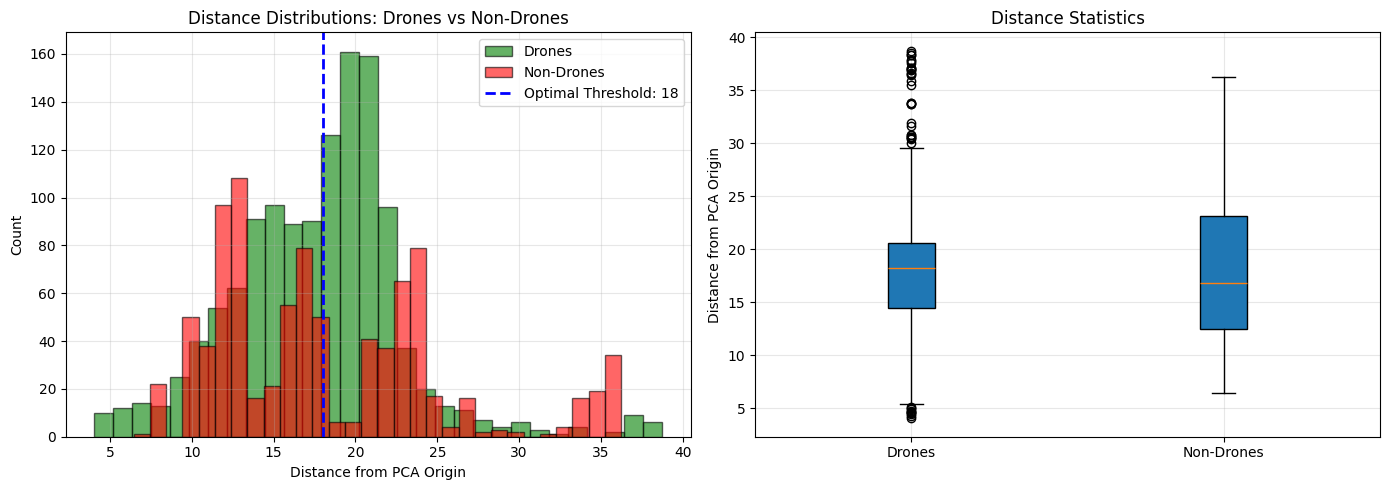


Classification at threshold 18:
  Drones recognized: 604/1262 (47.9%)
  False positives (non-drones detected as drones): 525/889 (59.1%)


In [18]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(train_distances, bins=30, alpha=0.6, label='Drones', color='green', edgecolor='black')
axes[0].hist(non_drone_distances, bins=30, alpha=0.6, label='Non-Drones', color='red', edgecolor='black')
axes[0].axvline(OPTIMAL_THRESHOLD, color='blue', linestyle='--', linewidth=2, label=f'Optimal Threshold: {OPTIMAL_THRESHOLD:.0f}')
axes[0].set_xlabel('Distance from PCA Origin')
axes[0].set_ylabel('Count')
axes[0].set_title('Distance Distributions: Drones vs Non-Drones')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Box plot
axes[1].boxplot([train_distances, non_drone_distances], labels=['Drones', 'Non-Drones'], patch_artist=True)
axes[1].set_ylabel('Distance from PCA Origin')
axes[1].set_title('Distance Statistics')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Compute confusion at optimal threshold
drone_correct = np.sum(train_distances < OPTIMAL_THRESHOLD)
drone_total = len(train_distances)
non_drone_fp = np.sum(non_drone_distances < OPTIMAL_THRESHOLD)
non_drone_total = len(non_drone_distances)

print(f"\nClassification at threshold {OPTIMAL_THRESHOLD:.0f}:")
print(f"  Drones recognized: {drone_correct}/{drone_total} ({100*drone_correct/drone_total:.1f}%)")
print(f"  False positives (non-drones detected as drones): {non_drone_fp}/{non_drone_total} ({100*non_drone_fp/non_drone_total:.1f}%)")

In [19]:

test_image1 = read_image('./example-test.jpg')
test_flat1 = flatten_image(test_image1, target_size=(64, 64))
test_image = read_image('./image_3.png')
test_flat = flatten_image(test_image, target_size=(64, 64))

#  the projection using the PCA function
test_projection = z_test(test_flat, mean_vector, evecs_1)

# Classify as drone or not
distances, is_drone_array = calculate_euclidean_distance(test_projection, MY_THRESHOLD)

dist = distances[0]
is_drone = is_drone_array[0]

if is_drone:
    print(f"This is a Drone! (Distance: {dist:.2f} < Threshold: {MY_THRESHOLD:.2f})")
else:
    print(f"This is NOT a Drone. (Distance: {dist:.2f} > Threshold: {MY_THRESHOLD:.2f})")

This is a Drone! (Distance: 15.88 < Threshold: 22.90)


In [20]:
def check_is_drone_no_background(test_flat, mean_vector, eigenvectors, drop_first_k=5):
    """
    Alternative drone detection using reconstruction error.
    Drops the first K eigenvectors (which capture background and lighting variations)
    and measures error when reconstructing from detail-only eigenvectors.

    Args:
        test_flat: Flattened test image [0, 1]
        mean_vector: Training data mean
        eigenvectors: PCA eigenvectors (D × k)
        drop_first_k: Number of dominant eigenvectors to skip (default: 5)

    Returns:
        relative_error: Reconstruction error normalized by image complexity
    """
    # Center the image
    centered_img = test_flat - mean_vector

    # Drop the first K eigenvectors (which capture background and lighting)
    # Keep all rows, but columns start from drop_first_k
    evecs_details = eigenvectors[:, drop_first_k:]

    # Project and reconstruct using ONLY the detail eigenvectors
    weights = np.dot(centered_img, evecs_details)
    reconstructed_img = np.dot(weights, evecs_details.T)

    # Compute reconstruction error
    abs_error = np.linalg.norm(centered_img - reconstructed_img)
    img_complexity = np.linalg.norm(centered_img)

    if img_complexity == 0:
        return 0.0

    relative_error = abs_error / img_complexity

    return relative_error

In [21]:
error_sky = check_is_drone_no_background(test_flat, mean_vector, evecs_1)
error_real_drone = check_is_drone_no_background(test_flat1, mean_vector, evecs_1)


proj_sky = z_test(test_flat, mean_vector, evecs_1)
proj_drone = z_test(test_flat1, mean_vector, evecs_1)


dist_sky = np.linalg.norm(proj_sky)
dist_drone = np.linalg.norm(proj_drone)


print(f"Reconstruction error (sky): {error_sky}")
print(f"Reconstruction error (drone): {error_real_drone}")

Reconstruction error (sky): 0.6596577276488103
Reconstruction error (drone): 0.7150619265362651


Drone found Distance: 10.47 (Threshold: 3000)


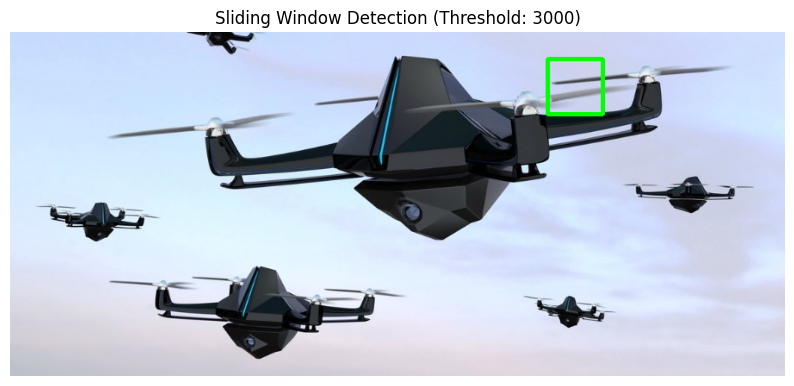

In [22]:
def detect_drone_sliding_window(large_image_path, mean_vector, eigenvectors, Z_train_drone=None, Z_train_non_drone=None, threshold=3600, window_size=(64, 64), step_size=16):
    img = cv2.imread(large_image_path)
    if img is None:
        print("Error: image not found!")
        return

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # For visualization
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # For computation

    best_dist = float('inf')
    best_box = None

    for y in range(0, img_gray.shape[0] - window_size[1], step_size):
        for x in range(0, img_gray.shape[1] - window_size[0], step_size):

            window = img_gray[y:y + window_size[1], x:x + window_size[0]]

            window_flat = window.flatten() / 255.0

            # 2. Project using the PCA function
            test_projection = z_test(window_flat, mean_vector, eigenvectors)

            # Handle both 1D and 2D projections
            if test_projection.ndim == 1:
                test_projection = test_projection.reshape(1, -1)

            dist = np.linalg.norm(test_projection, axis=1)[0]

            # 3. Find the window with smallest distance below threshold
            if dist < threshold and dist < best_dist:
                best_dist = dist
                best_box = (x, y, window_size[0], window_size[1])

    # 4. Draw results
    result_img = img_rgb.copy()
    if best_box is not None:
        x, y, w, h = best_box
        cv2.rectangle(result_img, (x, y), (x+w, y+h), (0, 255, 0), 3)
        print(f"Drone found Distance: {best_dist:.2f} (Threshold: {threshold})")
    else:
        print(f" No drones found (All distances > {threshold}).")

    plt.figure(figsize=(10, 8))
    plt.imshow(result_img)
    plt.axis('off')
    plt.title(f"Sliding Window Detection (Threshold: {threshold})")
    plt.show()

test_large_img_path = './archive/drone_dataset_yolo/dataset_txt/0001.jpg'
detect_drone_sliding_window(test_large_img_path, mean_vector, evecs_1, threshold=3000)